# Supply Chain Analytics - Anomaly Detection

## Objective

The objective of this notebook is to identify unusual demand patterns in the
supply chain using statistical anomaly detection techniques.

Methods used:

- Z-Score
- Interquartile Range (IQR)

The detected anomalies may indicate unexpected demand spikes, stock issues,
promotions, seasonal events, or operational problems.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [2]:
df= pd.read_csv("../data/cleaned/retail_store_inventory_cleaned.csv",parse_dates=["Date"])

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
daily_sales = (
    df.groupby("Date")["Units Sold"]
      .sum()
      .reset_index())

daily_sales.head()

,Date,Units Sold
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


In [4]:
print("Rows :", daily_sales.shape[0])
print("Columns :", daily_sales.shape[1])

daily_sales.describe()

Rows : 731
Columns : 2


,Date,Units Sold
count,731,731.000000
mean,2023-01-01 00:00:00,13646.487004
min,2022-01-01 00:00:00,10642.000000
25%,2022-07-02 12:00:00,12981.000000
50%,2023-01-01 00:00:00,13673.000000
75%,2023-07-02 12:00:00,14323.500000
max,2024-01-01 00:00:00,17239.000000
std,NaN,1031.958966


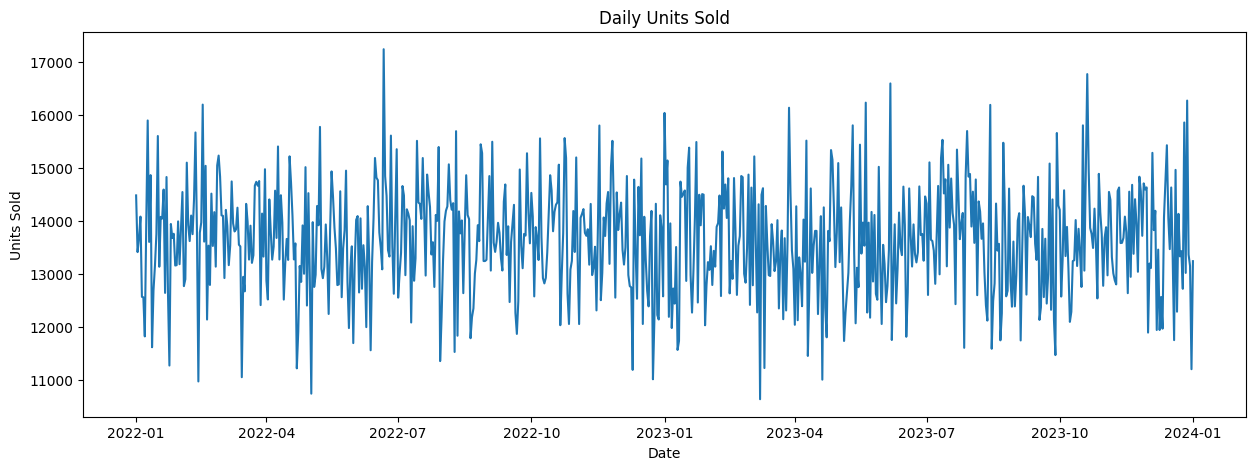

In [5]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"])

plt.title("Daily Units Sold")

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

## Z-Score Anomaly Detection

The Z-Score method measures how far each observation deviates from the mean in terms of standard deviations.

Observations with an absolute Z-Score greater than 3 are considered statistical anomalies.

This method helps identify unusually high or low daily sales that may indicate unexpected business events or operational issues.

In [6]:
daily_sales["Z-Score"] = zscore(daily_sales["Units Sold"])

daily_sales.head()

,Date,Units Sold,Z-Score
0,2022-01-01,14484,0.812132
1,2022-01-02,13415,-0.224472
2,2022-01-03,13681,0.033467
3,2022-01-04,14084,0.424254
4,2022-01-05,12572,-1.041924


In [7]:
daily_sales["Z_Anomaly"] = (
    abs(daily_sales["Z-Score"]) > 3
)

daily_sales.head()

,Date,Units Sold,Z-Score,Z_Anomaly
0,2022-01-01,14484,0.812132,False
1,2022-01-02,13415,-0.224472,False
2,2022-01-03,13681,0.033467,False
3,2022-01-04,14084,0.424254,False
4,2022-01-05,12572,-1.041924,False


### Number of Detected Anomalies

The following cell displays the total number of observations identified as anomalies using the Z-Score method.

In [8]:
print("Total anomalies:", daily_sales["Z_Anomaly"].sum())

Total anomalies: 2


### Detected Anomalies

The table below lists all daily sales observations that exceed the Z-Score threshold and are classified as anomalies.

In [9]:
zscore_anomalies = daily_sales[daily_sales["Z_Anomaly"]]

zscore_anomalies

,Date,Units Sold,Z-Score,Z_Anomaly
171,2022-06-21,17239,3.483639,True
657,2023-10-20,16770,3.028853,True


## Visualization of Z-Score Anomalies

The scatter plot highlights anomalous observations detected using the Z-Score method.

Red markers indicate days where the sales significantly deviate from the overall sales distribution.

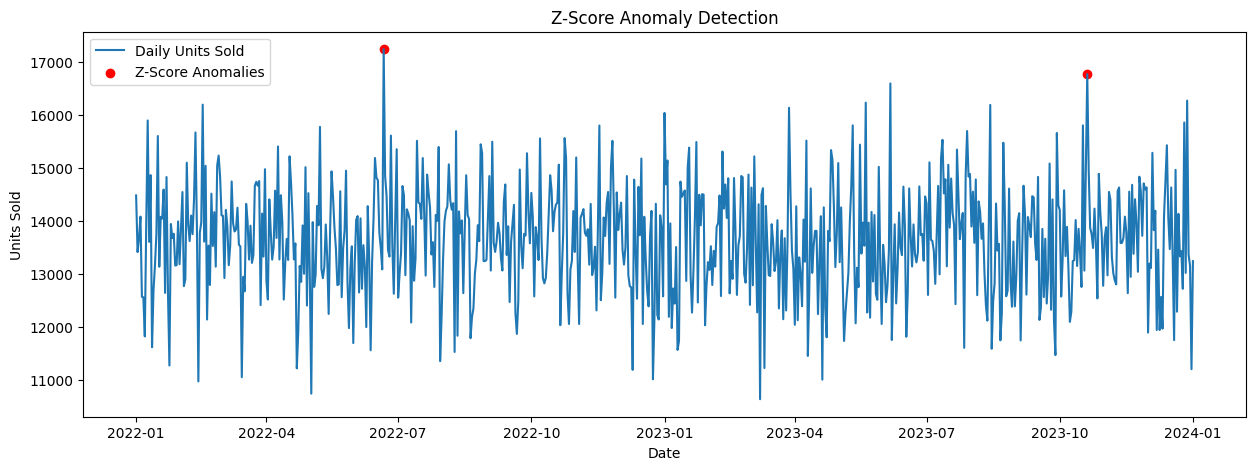

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"],
    label="Daily Units Sold"
)

plt.scatter(
    zscore_anomalies["Date"],
    zscore_anomalies["Units Sold"],
    color="red",
    label="Z-Score Anomalies"
)

plt.title("Z-Score Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.show()